## Problem Statement


### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.


### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.


### Data Dictionary

- `ID`: Customer ID
- `Age`: Customer’s age in completed years
- `Experience`: #years of professional experience
- `Income`: Annual income of the customer (in thousand dollars)
- `ZIP Code`: Home Address ZIP code.
- `Family`: the Family size of the customer
- `CCAvg`: Average spending on credit cards per month (in thousand dollars)
- `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
- `Mortgage`: Value of house mortgage if any. (in thousand dollars)
- `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
- `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
- `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
- `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
- `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)


## Importing necessary libraries


In [134]:
# Installing the libraries with the specified version.
%pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 sklearn-pandas==2.2.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.


In [135]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
)

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset


In [136]:
df = pd.read_csv("data/Loan_Modelling.csv")


## Data Overview


- Observations
- Sanity checks


In [137]:

# simply use pandas methods to get an overview of the data, and some quick obervations

print(df.describe())
print(df.info())
print("Shape: ", df.shape)

print(df.head())
print(df.tail())

                ID          Age   Experience       Income       ZIPCode  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.104600    73.774200  93169.257000   
std    1443.520003    11.463166    11.467954    46.033729   1759.455086   
min       1.000000    23.000000    -3.000000     8.000000  90005.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal_Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.294621   
min       1.000000  

## Exploratory Data Analysis.


- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.


**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

There seems to be a high variability, as the standard deviation is ~101. Furthermore, the mean being ~56 and the median being 0 suggests a significant right skew. This suggests significant upper outliers pulling the distrubtion higher.

2. How many customers have credit cards?

1470

3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

The attributes that have a noticeable correlation with personal loan are: Income (0.502462), CCAvg (0.366889), and CD_Account (0.316355)

4. How does a customer's interest in purchasing a loan vary with their age?

It seems age has little to do with the customers interest. It only varies from 8%-10% for each age group.

5. How does a customer's interest in purchasing a loan vary with their education?

It seems the more educated someone is, the more likely they are to accept a loan. 1 education has to lowest acceptance rate, whereas 3 is the highest.


Mortgage feature info:  count    5000.000000
mean       56.498800
std       101.713802
min         0.000000
25%         0.000000
50%         0.000000
75%       101.000000
max       635.000000
Name: Mortgage, dtype: float64
Mortgage feature median:  0.0
Mortgage skew:  2.1040023191079444


Num cc havers:  1470


Strong correlation:
 Income        0.502462
CCAvg         0.366889
CD_Account    0.316355
Name: Personal_Loan, dtype: float64


Personal Loan distribution by Age Group:
           Num_Customers  Num_Loans  Acceptance_Rate
AgeGroup                                           
20s                 624         66         0.105769
30s                1236        118         0.095469
40s                1270        122         0.096063
50s                1323        115         0.086924
60s                 547         59         0.107861
70s                   0          0              NaN


Personal Loan distribution by Education:
            Num_Customers  Num_Loans  Acceptance_Rate
Educ

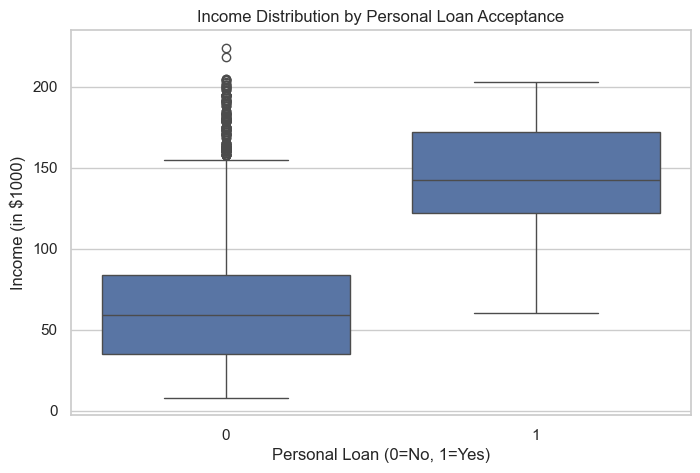

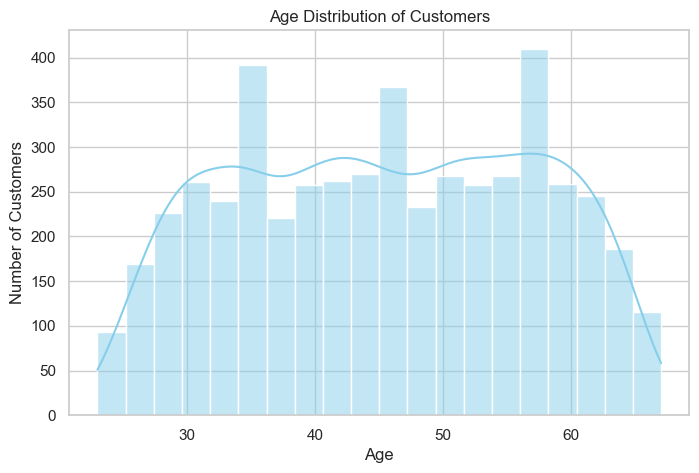

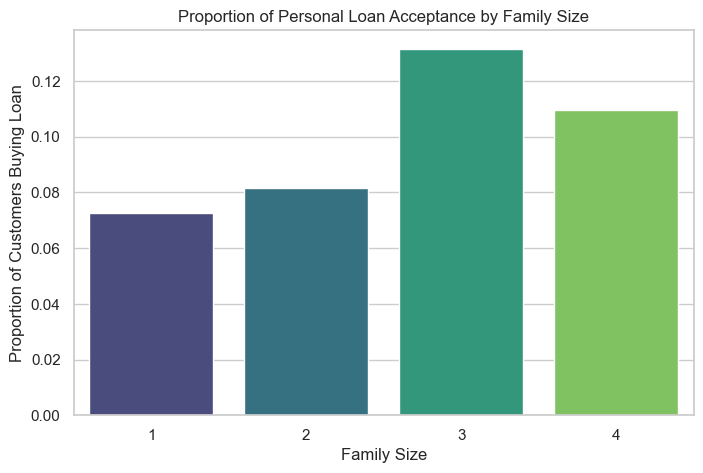

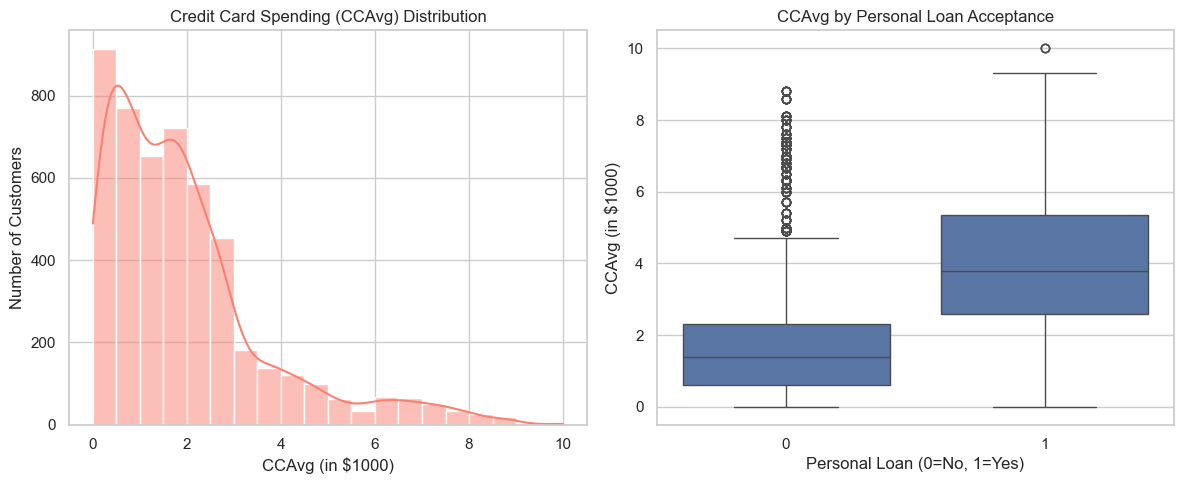

In [138]:
# 1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?

print("Mortgage feature info: ", df.Mortgage.describe())
print("Mortgage feature median: ", df.Mortgage.median())
print("Mortgage skew: ",df.Mortgage.skew())

# 2. How many customers have credit cards?

# get num credit card holders
num_customers_with_cc = df[df["CreditCard"] == 1].shape[0]
print("\n\nNum cc havers: ", num_customers_with_cc)

# 3. What are the attributes that have a strong correlation with the target attribute (personal loan)?

corr = df.corr()
target_corr = corr["Personal_Loan"]
# Absolute value, exclude the target itself
strong_corr = target_corr[abs(target_corr) > 0.3].drop("Personal_Loan")
print("\n\nStrong correlation:\n", strong_corr.sort_values(ascending=False))


# 4. How does a customer's interest in purchasing a loan vary with their age?

# get distribtion of personal loan grouped by age group
# For EDA only
tmpDf = df.copy()
tmpDf['AgeGroup'] = pd.cut(tmpDf['Age'], bins=[20,30,40,50,60,70,80], labels=['20s','30s','40s','50s','60s','70s'])

agegroup_summary = tmpDf.groupby("AgeGroup")["Personal_Loan"].agg(
    Num_Customers="count",
    Num_Loans="sum",
    Acceptance_Rate="mean"
)
print("\n\nPersonal Loan distribution by Age Group:\n", agegroup_summary)

# 5. How does a customer's interest in purchasing a loan vary with their education?

# same as above, just no bins

education_summary = df.groupby("Education")["Personal_Loan"].agg(
    Num_Customers="count",
    Num_Loans="sum",
    Acceptance_Rate="mean"
)

print("\n\nPersonal Loan distribution by Education:\n", education_summary)


## General Data analysis (plots)

sns.set(style="whitegrid")

# Income vs Personal_Loan (Boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(x="Personal_Loan", y="Income", data=df)
plt.title("Income Distribution by Personal Loan Acceptance")
plt.xlabel("Personal Loan (0=No, 1=Yes)")
plt.ylabel("Income (in $1000)")
plt.show()

# Age Distribution (Histogram)
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True, color="skyblue")
plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

# Family Size vs Personal Loan (Barplot of proportion)
family_loan = df.groupby("Family")["Personal_Loan"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x="Family", y="Personal_Loan", data=family_loan, palette="viridis")
plt.title("Proportion of Personal Loan Acceptance by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Proportion of Customers Buying Loan")
plt.show()

# CCAvg vs Personal Loan (Histogram + Boxplot)
plt.figure(figsize=(12,5))

# Histogram
plt.subplot(1,2,1)
sns.histplot(df["CCAvg"], bins=20, kde=True, color="salmon")
plt.title("Credit Card Spending (CCAvg) Distribution")
plt.xlabel("CCAvg (in $1000)")
plt.ylabel("Number of Customers")

# Boxplot
plt.subplot(1,2,2)
sns.boxplot(x="Personal_Loan", y="CCAvg", data=df)
plt.title("CCAvg by Personal Loan Acceptance")
plt.xlabel("Personal Loan (0=No, 1=Yes)")
plt.ylabel("CCAvg (in $1000)")

plt.tight_layout()
plt.show()





## Data Preprocessing


- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)


In [139]:
# missing value treatment test (not necessary) and suplicate check


print("Null: ", df.isnull().sum())
print("Duplicate: ", df.duplicated().sum())


X = df.drop(["Personal_Loan"], axis=1)
X = X.astype(float)
Y = df.Personal_Loan

# splitting data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.3, random_state=1)


print(f"Training X shape: {X_train.shape}")
print(f"Training Y: {Y_train.value_counts(True)}")
print(f"Test X shape: {X_test.shape}")
print(f"Test Y shape: {Y_test.value_counts(True)}")


# there are no catgorical variables


Null:  ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64
Duplicate:  0
Training X shape: (3500, 13)
Training Y: Personal_Loan
0    0.905429
1    0.094571
Name: proportion, dtype: float64
Test X shape: (1500, 13)
Test Y shape: Personal_Loan
0    0.900667
1    0.099333
Name: proportion, dtype: float64


## Model Building


### Model Evaluation Criterion


### Model can make wrong predictions as:

- Predicting someone will buy a loan when they will not (False Postive)
- Predicting someone will not buy a loan when they will (False Negative)

The most important case to worry about are False Negatives, as the bank would be losing out on potential customers.


In [140]:



def model_performance_classification_sklearn(model, predictors, target):

    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall":recall, "Precision": precision, "F1": f1}, index=[0]
    )

    return df_perf

In [141]:
from sklearn.metrics import confusion_matrix


def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

## Model Building


In [142]:
# this is a function to fit and diplay a model

def fit_and_display_model(model):
    model.fit(X_train, Y_train)

    print("===== TRAIN =====")

    print("ConfUSION MATRIX (TRAIN)")
    confusion_matrix_sklearn(model, X_train, Y_train)

    print("METRICS (TRAIN)")
    print(model_performance_classification_sklearn(model, X_train, Y_train))

    print("\n===== TEST =====")

    print("CONFUSION MATRIX (TEST)")
    confusion_matrix_sklearn(model, X_test, Y_test)

    print("METRICS (TEST)")
    print(model_performance_classification_sklearn(model, X_test, Y_test))

### Default


===== TRAIN =====
ConfUSION MATRIX (TRAIN)


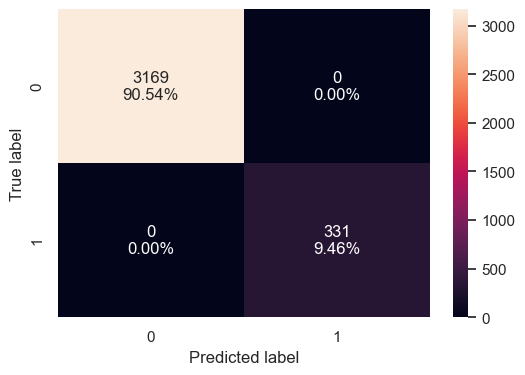

METRICS (TRAIN)
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

===== TEST =====
CONFUSION MATRIX (TEST)


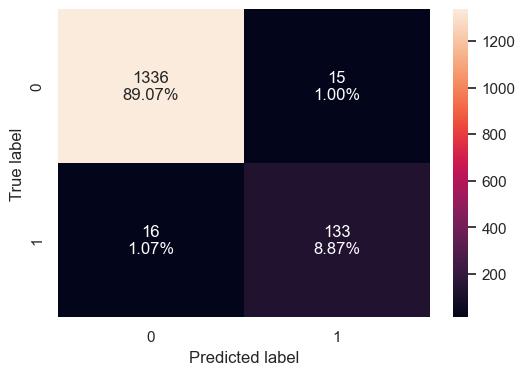

METRICS (TEST)
   Accuracy    Recall  Precision        F1
0  0.979333  0.892617   0.898649  0.895623


In [143]:
model0 = DecisionTreeClassifier(random_state=1)
fit_and_display_model(model0)


### With Class Weights

No improvement from this technique


===== TRAIN =====
ConfUSION MATRIX (TRAIN)


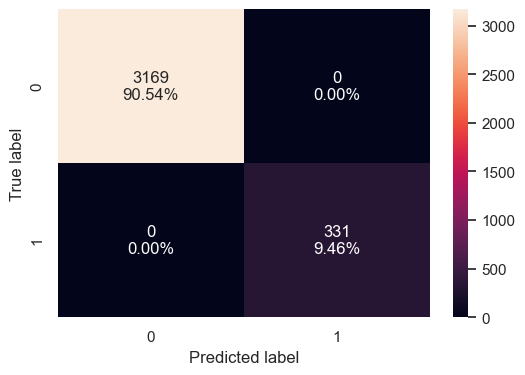

METRICS (TRAIN)
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

===== TEST =====
CONFUSION MATRIX (TEST)


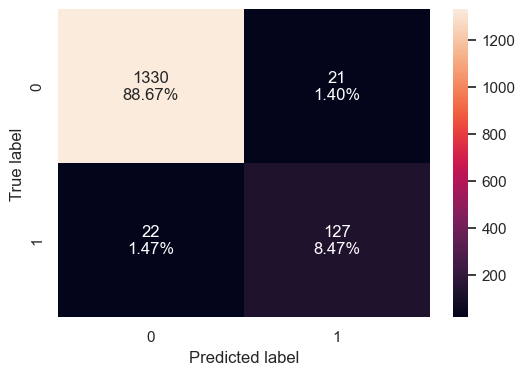

METRICS (TEST)
   Accuracy    Recall  Precision        F1
0  0.971333  0.852349   0.858108  0.855219


In [144]:
model1 = DecisionTreeClassifier(random_state=1, class_weight="balanced")
fit_and_display_model(model1)

Pre-Pruning
(we will prioritize recall as those are the customers who would have purchased a loan)


Best parameters found:
Max depth: 2
Max leaf nodes: 50
Min samples split: 10
Best test recall score: 1.0
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


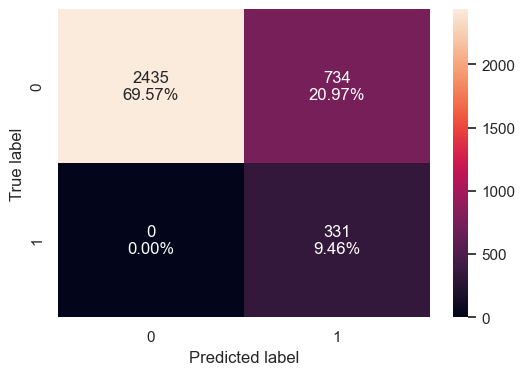

METRICS (TRAIN)
   Accuracy  Recall  Precision        F1
0  0.790286     1.0   0.310798  0.474212

===== TEST =====
CONFUSION MATRIX (TEST)


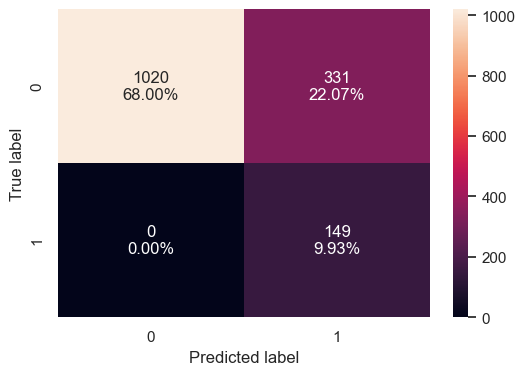

METRICS (TEST)
   Accuracy  Recall  Precision        F1
0  0.779333     1.0   0.310417  0.473768


In [145]:
import sys
# define paramters

max_depth_values = np.arange(2,7, 1)
max_leaf_nodes_values = np.arange(50, 250, 50)
min_samples_split_values = np.arange(10, 70, 20)

# variables to store best performace model
best_model = None
best_score_diff = sys.maxsize
best_test_score = -sys.maxsize

for depth in max_depth_values:
    for leaf_nodes in max_leaf_nodes_values:
        for samples_split in min_samples_split_values:

            tmp_model = DecisionTreeClassifier(
                max_depth=depth,
                max_leaf_nodes=leaf_nodes,
                min_samples_split=samples_split,
                class_weight='balanced',
                random_state=42
            )

            # fit a temp model
            tmp_model.fit(X_train, Y_train)

            # Make predictions

            y_train_pred = tmp_model.predict(X_train)
            y_test_pred = tmp_model.predict(X_test)

            # Calc scores

            train_recall = recall_score(Y_train, y_train_pred)
            test_recall = recall_score(Y_test, y_test_pred)

            score_diff = abs(train_recall - test_recall)

            if score_diff < best_score_diff and test_recall > best_test_score:
                best_score_diff = score_diff
                best_test_score = test_recall
                best_model = tmp_model 


print("Best parameters found:")
print(f"Max depth: {best_model.max_depth}")
print(f"Max leaf nodes: {best_model.max_leaf_nodes}")
print(f"Min samples split: {best_model.min_samples_split}")
print(f"Best test recall score: {best_test_score}")

fit_and_display_model(best_model)



=================== DEFAULT ===================


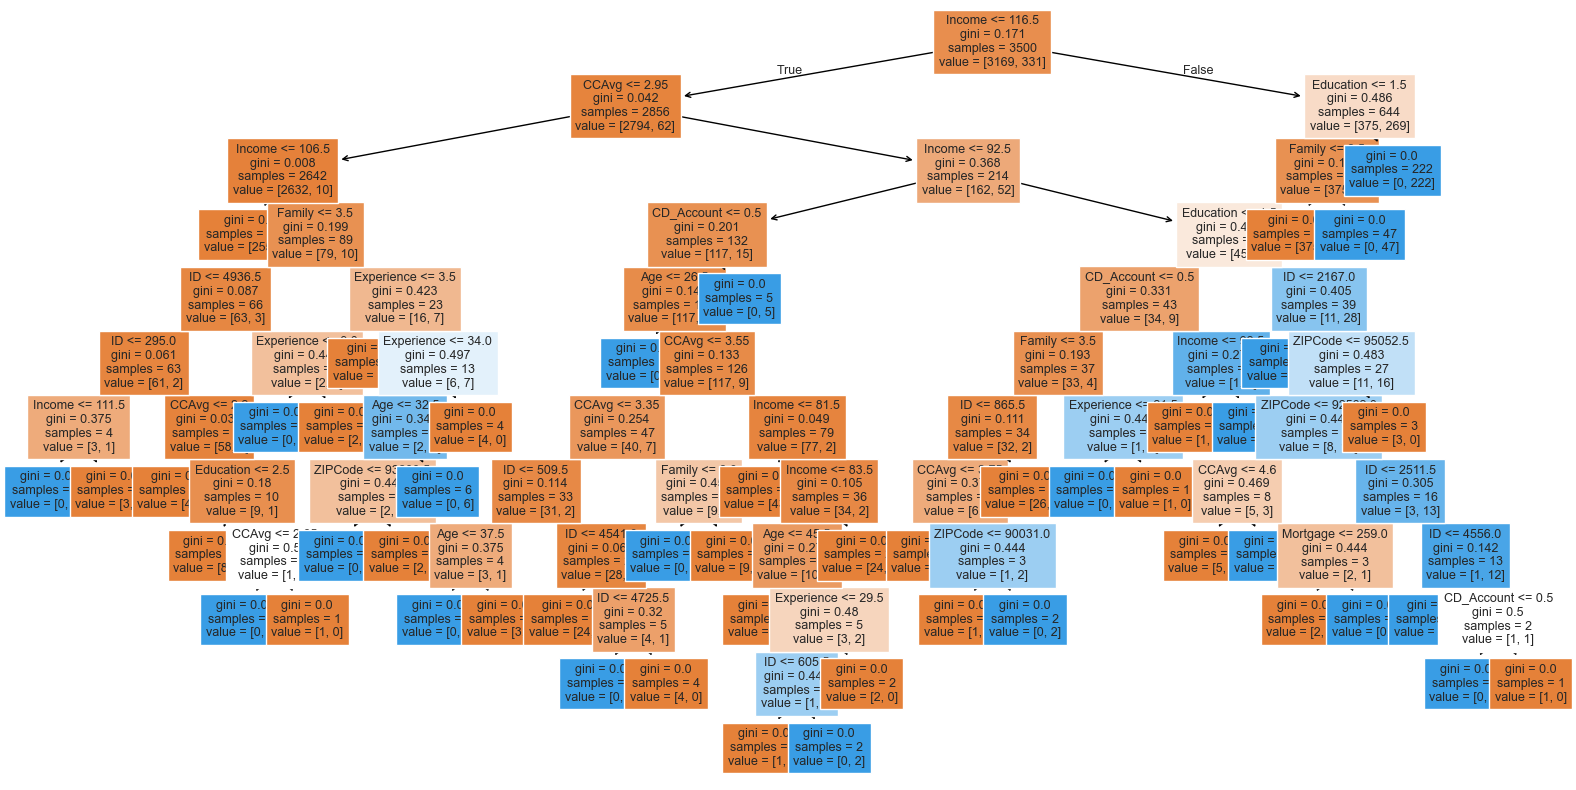

|--- Income <= 116.50
|   |--- CCAvg <= 2.95
|   |   |--- Income <= 106.50
|   |   |   |--- weights: [2553.00, 0.00] class: 0
|   |   |--- Income >  106.50
|   |   |   |--- Family <= 3.50
|   |   |   |   |--- ID <= 4936.50
|   |   |   |   |   |--- ID <= 295.00
|   |   |   |   |   |   |--- Income <= 111.50
|   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |--- Income >  111.50
|   |   |   |   |   |   |   |--- weights: [3.00, 0.00] class: 0
|   |   |   |   |   |--- ID >  295.00
|   |   |   |   |   |   |--- CCAvg <= 2.20
|   |   |   |   |   |   |   |--- weights: [49.00, 0.00] class: 0
|   |   |   |   |   |   |--- CCAvg >  2.20
|   |   |   |   |   |   |   |--- Education <= 2.50
|   |   |   |   |   |   |   |   |--- weights: [8.00, 0.00] class: 0
|   |   |   |   |   |   |   |--- Education >  2.50
|   |   |   |   |   |   |   |   |--- CCAvg <= 2.65
|   |   |   |   |   |   |   |   |   |--- weights: [0.00, 1.00] class: 1
|   |   |   |   |   |   |   |   |--- 

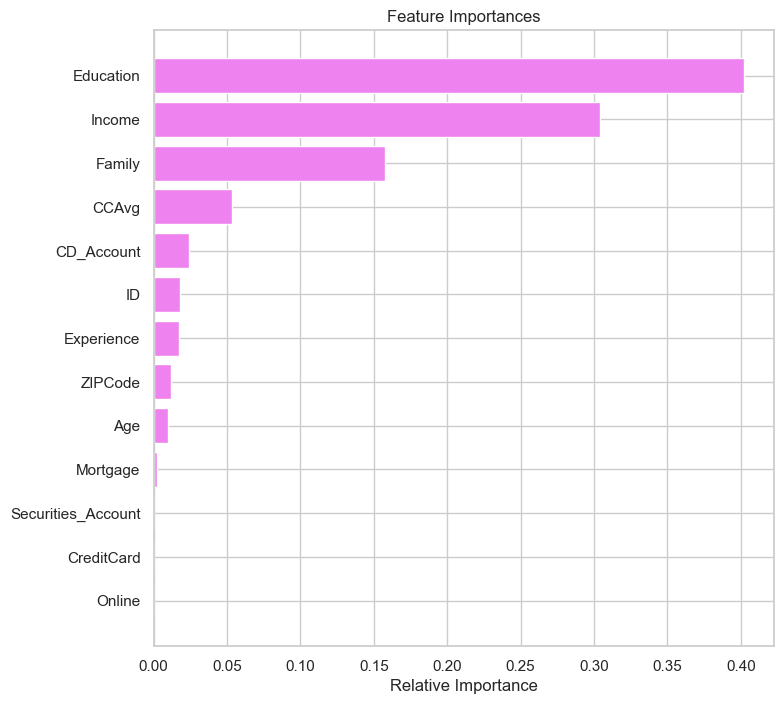



=================== CLASS WEIGHTS ===================


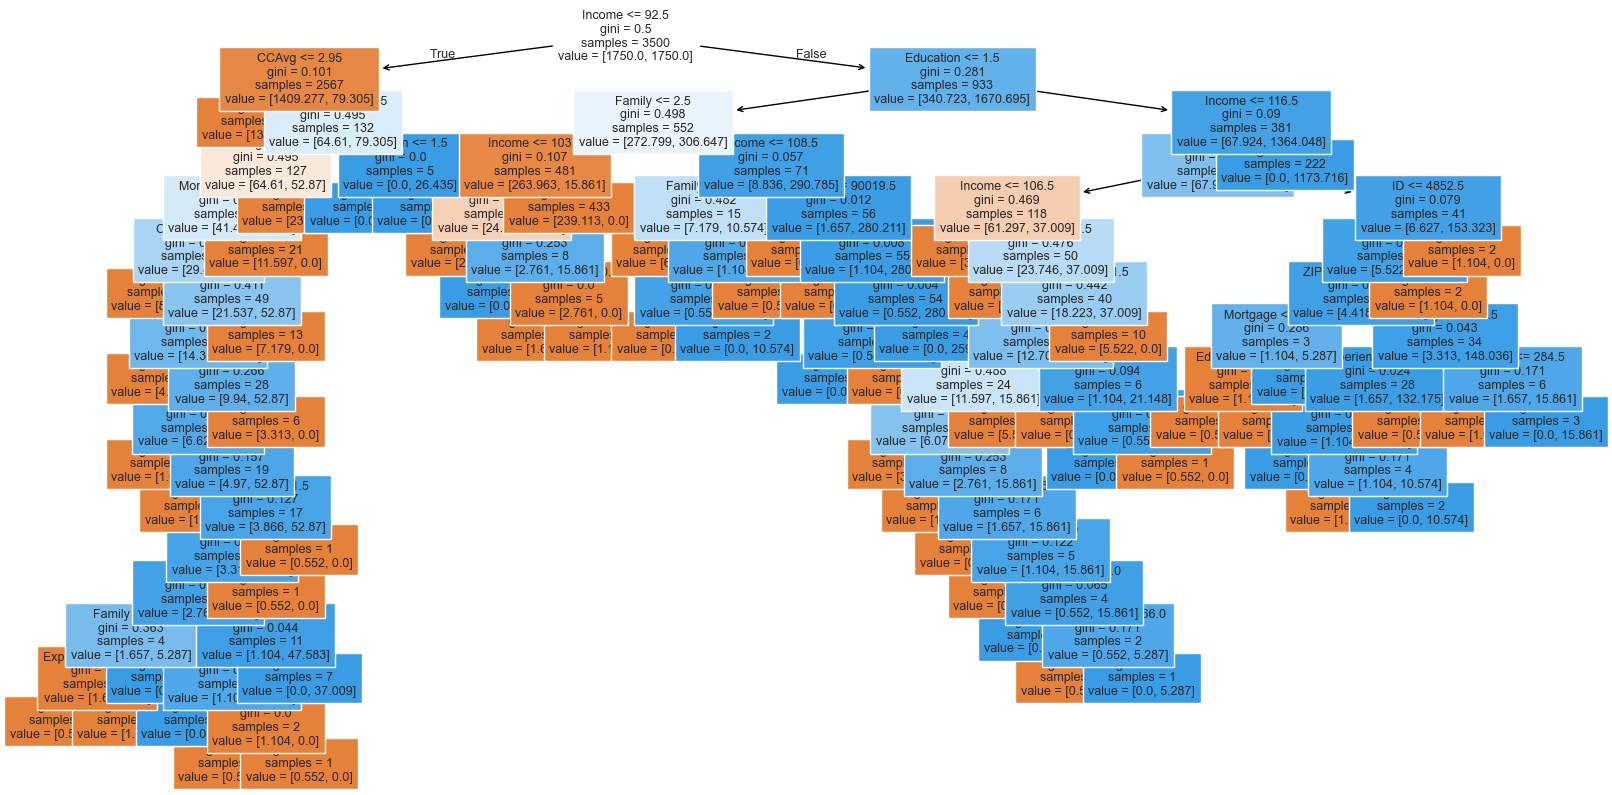

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- CD_Account <= 0.50
|   |   |   |--- CCAvg <= 3.95
|   |   |   |   |--- Mortgage <= 102.50
|   |   |   |   |   |--- CCAvg <= 3.05
|   |   |   |   |   |   |--- weights: [8.28, 0.00] class: 0
|   |   |   |   |   |--- CCAvg >  3.05
|   |   |   |   |   |   |--- Family <= 3.50
|   |   |   |   |   |   |   |--- Income <= 67.00
|   |   |   |   |   |   |   |   |--- weights: [4.42, 0.00] class: 0
|   |   |   |   |   |   |   |--- Income >  67.00
|   |   |   |   |   |   |   |   |--- ZIPCode <= 94714.50
|   |   |   |   |   |   |   |   |   |--- ZIPCode <= 90437.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [1.66, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |--- ZIPCode >  90437.50
|   |   |   |   |   |   |   |   |   |   |--- ID <= 484.00
|   |   |   |   |   |   |   |   |   |   |   |--- weights: [1.10, 0.00] class: 0
|   |   |   |   |   |   |   |   |   |   |-

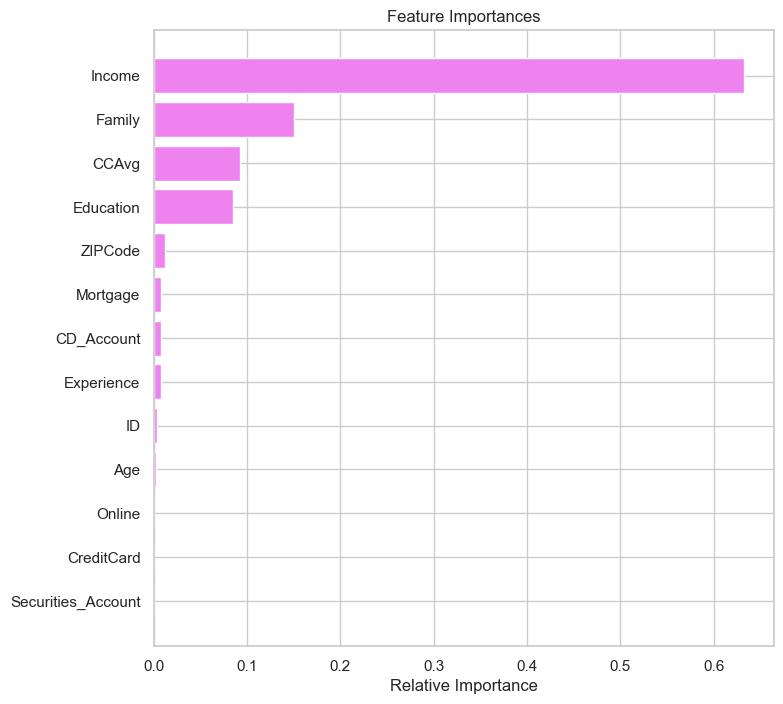



=================== PRE-PRUNING ===================


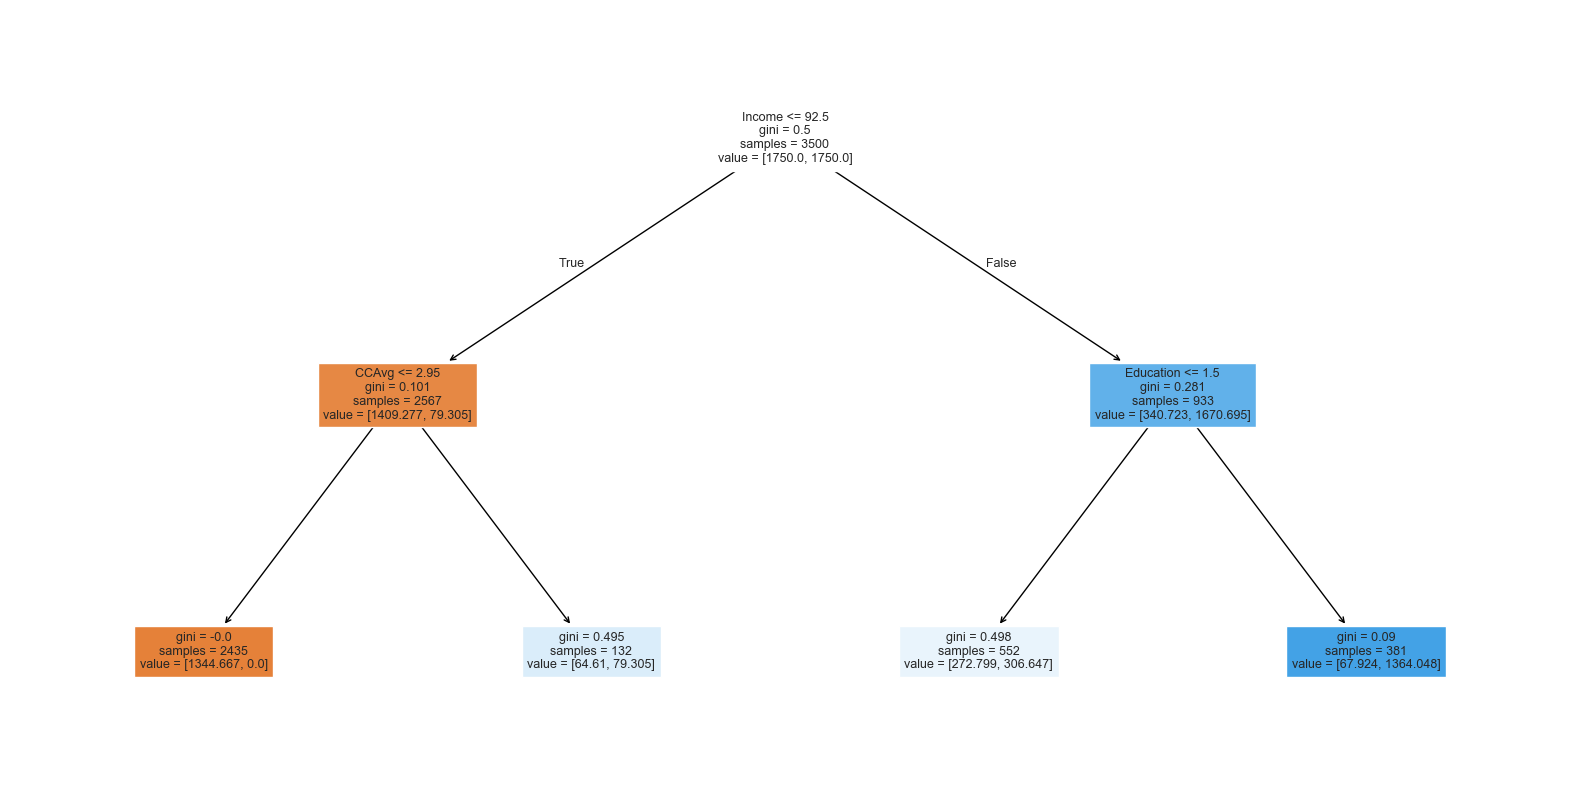

|--- Income <= 92.50
|   |--- CCAvg <= 2.95
|   |   |--- weights: [1344.67, 0.00] class: 0
|   |--- CCAvg >  2.95
|   |   |--- weights: [64.61, 79.31] class: 1
|--- Income >  92.50
|   |--- Education <= 1.50
|   |   |--- weights: [272.80, 306.65] class: 1
|   |--- Education >  1.50
|   |   |--- weights: [67.92, 1364.05] class: 1



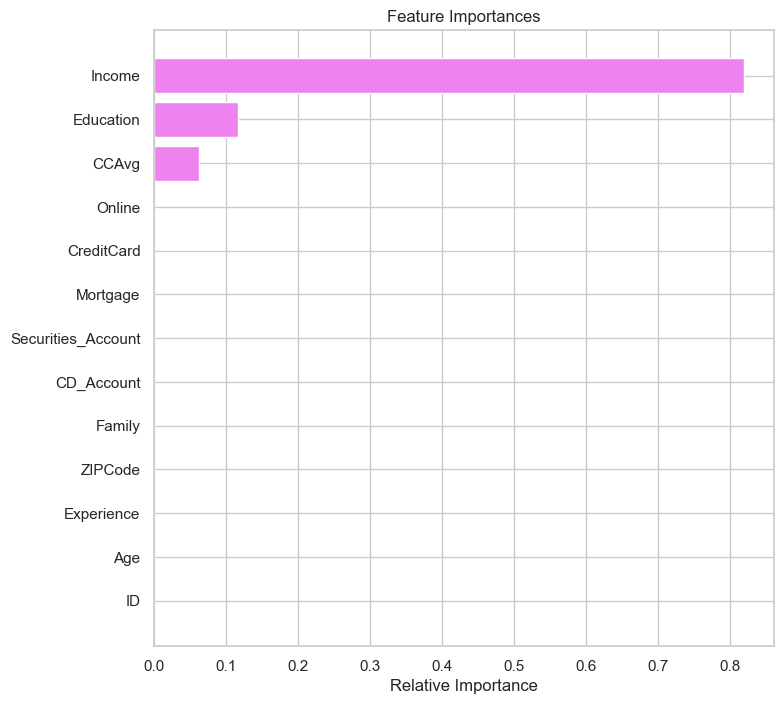

In [146]:
# Print the models

def print_decision_tree(model):
    feature_names = list(X_train.columns)
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(20, 10))
    out = tree.plot_tree(
        model,
        feature_names=feature_names,
        filled=True,
        fontsize=9,
        node_ids=False,
        class_names=None,
    )
    # below code will add arrows to the decision tree split if they are missing
    for o in out:
        arrow = o.arrow_patch
        if arrow is not None:
            arrow.set_edgecolor("black")
            arrow.set_linewidth(1)
    plt.show()
    print(tree.export_text(model, feature_names=feature_names, show_weights=True))

    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure(figsize=(8, 8))
    plt.title("Feature Importances")
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()

print("=================== DEFAULT ===================")
print_decision_tree(model0.fit(X_train, Y_train))
print("\n\n=================== CLASS WEIGHTS ===================")
print_decision_tree(model1.fit(X_train, Y_train))
print("\n\n=================== PRE-PRUNING ===================")
print_decision_tree(best_model.fit(X_train, Y_train))

model2 = best_model



## Model Performance Improvement (Post-Pruning)


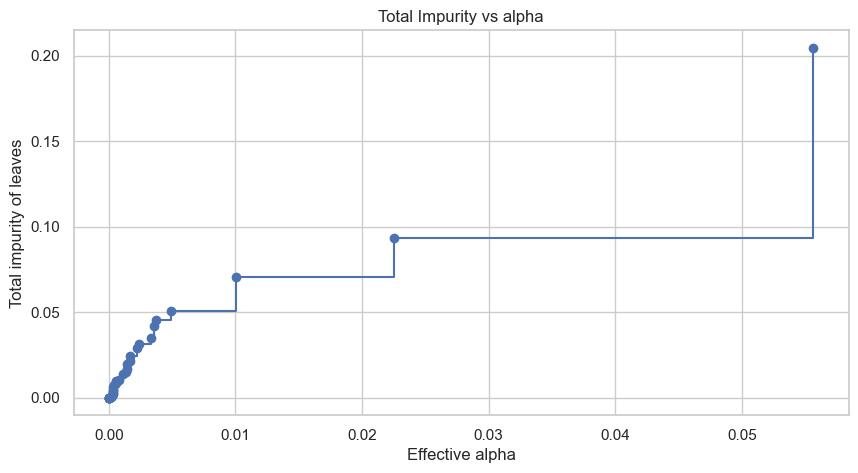

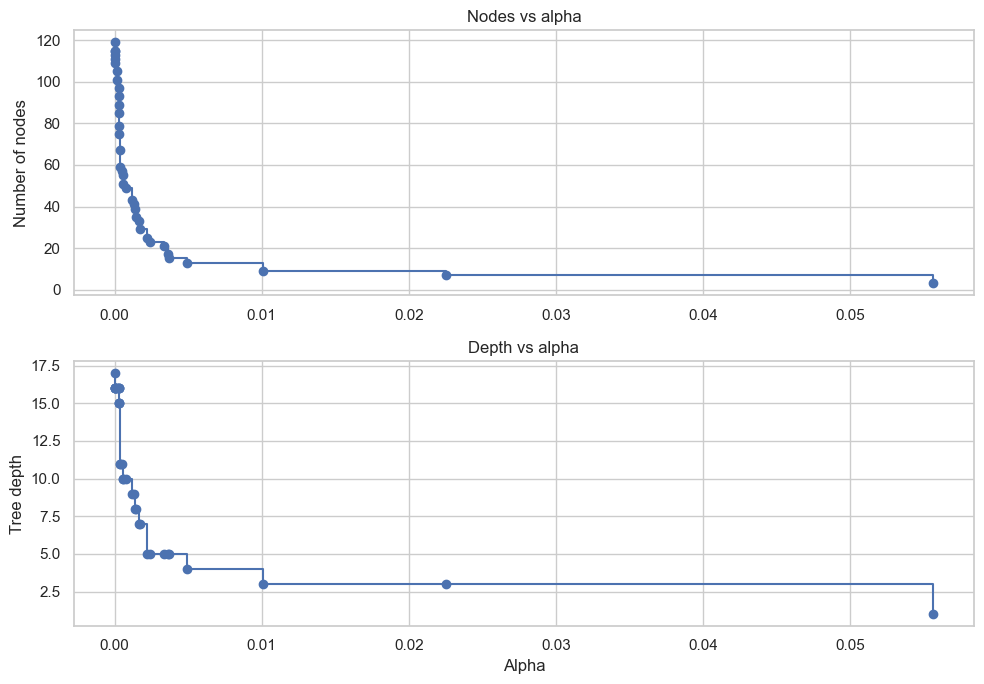

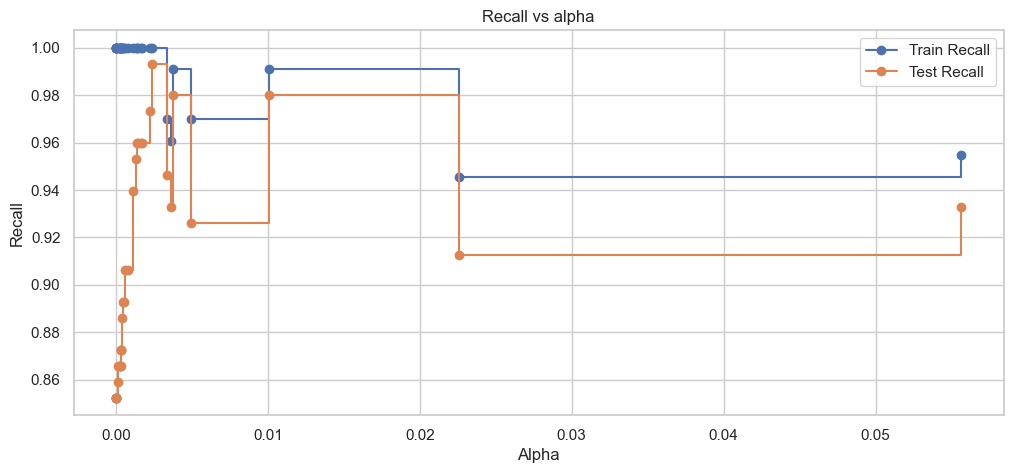

Best alpha: 0.0023758086197746466, Test Recall: 0.9932885906040269
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


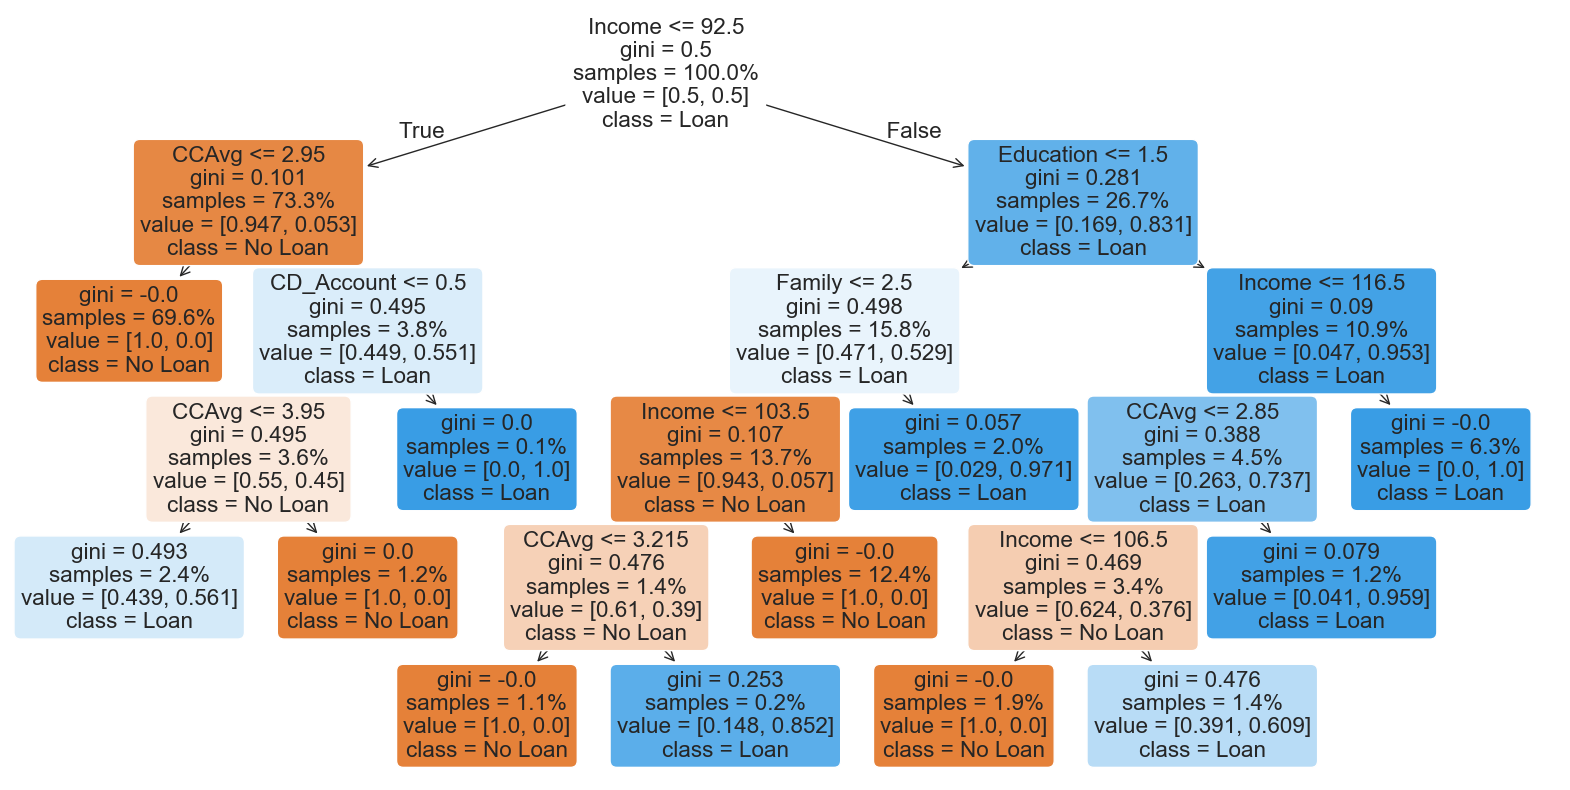

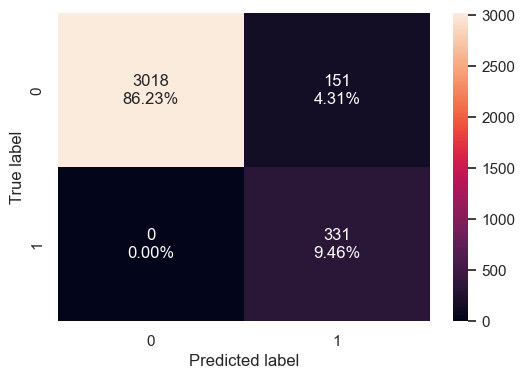

METRICS (TRAIN)
   Accuracy  Recall  Precision        F1
0  0.956857     1.0   0.686722  0.814268

===== TEST =====
CONFUSION MATRIX (TEST)


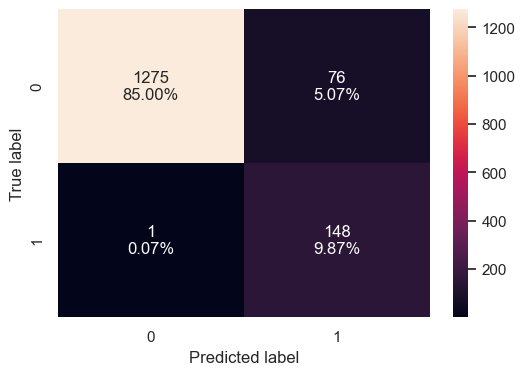

METRICS (TEST)
   Accuracy    Recall  Precision        F1
0  0.948667  0.993289   0.660714  0.793566


In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Fit initial tree and get pruning path
clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train, Y_train)
ccp_alphas = path.ccp_alphas[:-1]  # ignore last alpha which prunes everything
impurities = path.impurities[:-1]

# Plot total impurity vs alpha
plt.figure(figsize=(10,5))
plt.plot(ccp_alphas, impurities, marker="o", drawstyle="steps-post")
plt.xlabel("Effective alpha")
plt.ylabel("Total impurity of leaves")
plt.title("Total Impurity vs alpha")
plt.show()

# Train trees for each alpha
clfs = []
for alpha in ccp_alphas:
    clf_alpha = DecisionTreeClassifier(random_state=1, class_weight="balanced", ccp_alpha=alpha)
    clf_alpha.fit(X_train, Y_train)
    clfs.append(clf_alpha)

# Number of nodes and depth vs alpha
node_counts = [clf.tree_.node_count for clf in clfs]
depths = [clf.tree_.max_depth for clf in clfs]

fig, ax = plt.subplots(2,1, figsize=(10,7))
ax[0].plot(ccp_alphas, node_counts, marker="o", drawstyle="steps-post")
ax[0].set_ylabel("Number of nodes")
ax[0].set_title("Nodes vs alpha")
ax[1].plot(ccp_alphas, depths, marker="o", drawstyle="steps-post")
ax[1].set_xlabel("Alpha")
ax[1].set_ylabel("Tree depth")
ax[1].set_title("Depth vs alpha")
plt.tight_layout()
plt.show()

# Recall vs alpha
recall_train = [recall_score(Y_train, clf.predict(X_train)) for clf in clfs]
recall_test = [recall_score(Y_test, clf.predict(X_test)) for clf in clfs]

plt.figure(figsize=(12,5))
plt.plot(ccp_alphas, recall_train, marker="o", label="Train Recall", drawstyle="steps-post")
plt.plot(ccp_alphas, recall_test, marker="o", label="Test Recall", drawstyle="steps-post")
plt.xlabel("Alpha")
plt.ylabel("Recall")
plt.title("Recall vs alpha")
plt.legend()
plt.show()


best_idx = np.argmax(recall_test)
best_alpha = ccp_alphas[best_idx]
best_model = clfs[best_idx]
model3 = best_model

print(f"Best alpha: {best_alpha}, Test Recall: {recall_test[best_idx]}")

# Display the tree
plt.figure(figsize=(20,10))
plot_tree(
    best_model, 
    feature_names=X_train.columns, 
    class_names=["No Loan", "Loan"], 
    filled=True, 
    rounded=True, 
    proportion=True
)
fit_and_display_model(model3)
plt.show()


## Model Performance Comparison and Final Model Selection


== MODEL 1 == 
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


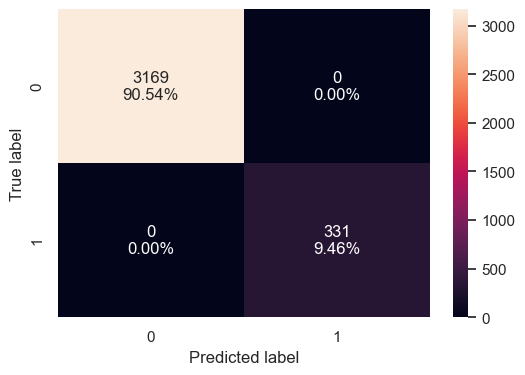

METRICS (TRAIN)
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

===== TEST =====
CONFUSION MATRIX (TEST)


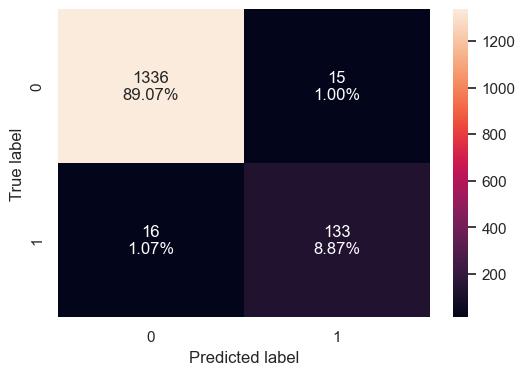

METRICS (TEST)
   Accuracy    Recall  Precision        F1
0  0.979333  0.892617   0.898649  0.895623
== MODEL 2 == 
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


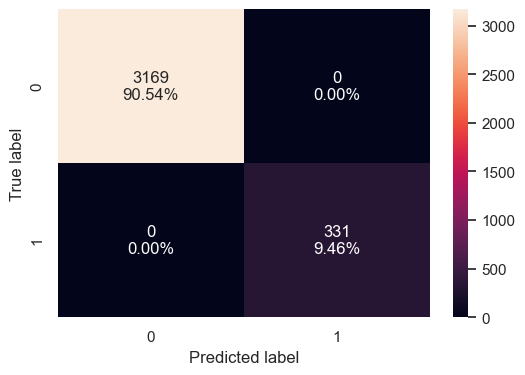

METRICS (TRAIN)
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0

===== TEST =====
CONFUSION MATRIX (TEST)


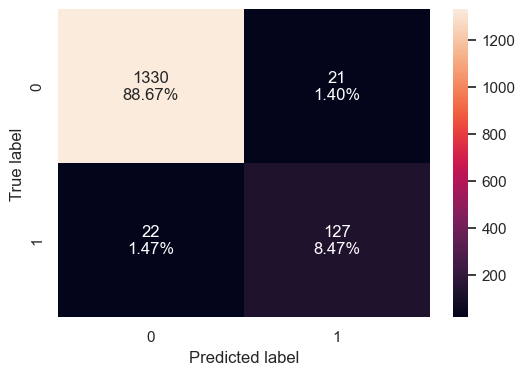

METRICS (TEST)
   Accuracy    Recall  Precision        F1
0  0.971333  0.852349   0.858108  0.855219
== MODEL 3 == 
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


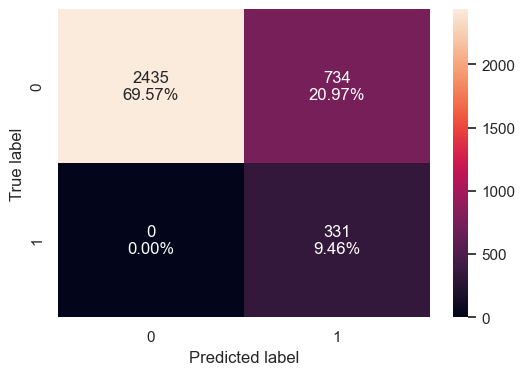

METRICS (TRAIN)
   Accuracy  Recall  Precision        F1
0  0.790286     1.0   0.310798  0.474212

===== TEST =====
CONFUSION MATRIX (TEST)


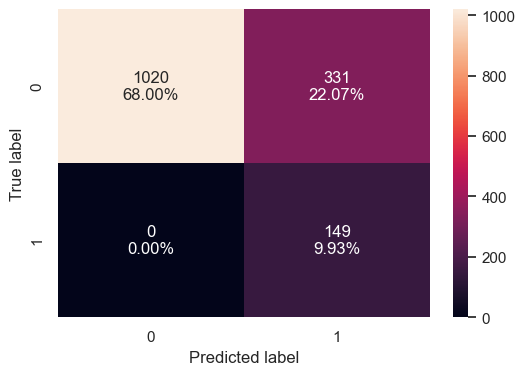

METRICS (TEST)
   Accuracy  Recall  Precision        F1
0  0.779333     1.0   0.310417  0.473768
== MODEL 4 == 
===== TRAIN =====
ConfUSION MATRIX (TRAIN)


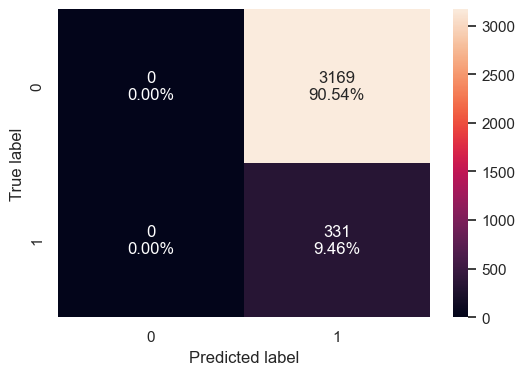

METRICS (TRAIN)
   Accuracy  Recall  Precision        F1
0  0.094571     1.0   0.094571  0.172801

===== TEST =====
CONFUSION MATRIX (TEST)


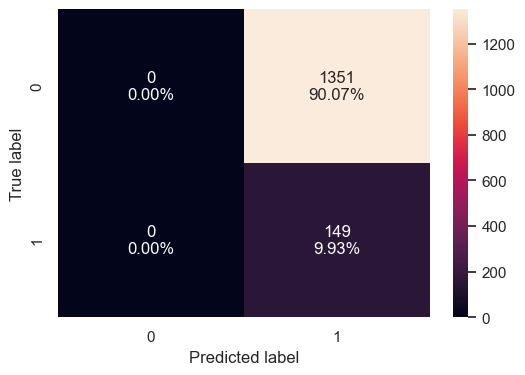

METRICS (TEST)
   Accuracy  Recall  Precision        F1
0  0.099333     1.0   0.099333  0.180716


In [148]:
print("== MODEL 1 == ")
fit_and_display_model(model0)
print("== MODEL 2 == ")
fit_and_display_model(model1)
print("== MODEL 3 == ")
fit_and_display_model(model2)
print("== MODEL 4 == ")
fit_and_display_model(model3)


If your priority is not missing any potential buyers, model 3 is the best. It ensures you capture nearly all interested customers. For personal loans, banks only care about finding as many qualified buyers as possible, so Model 3 is a good choice if your marketing budget can handle some false positives.


## Actionable Insights and Business Recommendations


- What recommedations would you suggest to the bank?

To maximize the amount of personal loans purchased, follow these rules:

- Target Higher-Income Customers
- Put less but most effot into Lower-Income, High-Spenders

## Subrgroups to not forget about to target:

- high-income, high-education
- Hight-income, low-education but large family
- Low-income, high credit card average

If you follow the groups listed in model 3 you will capture nearly all buyers, so more money spent on marketing to hit all of these groups will benefit you the most.


---
